In [1]:
import pandas as pd
import numpy as np

In [2]:
master = pd.read_csv(r"C:\Users\Admin\Desktop\IIMSTC\MINI PROJECT\E_Waste_Prediction_Project\master_dataset.csv")
master.head()

,Country,Year,E_Waste,GNI,Internet_Users,Electronics_Imports,GDP_Growth,Urban_Population,Total_Population
0,Brazil,2019,10.200,9410.0,73.9124,35.2,1.2,181356195,206338066
1,Brazil,2020,10.554,8080.0,81.3427,38.4,-3.3,183589871,208814123
2,Brazil,2021,10.921,8060.0,80.6899,45.6,4.8,185850085,211319892
3,Brazil,2022,11.300,8440.0,80.5278,42.1,3.0,188137144,213855731
4,Brazil,2023,11.692,9310.0,84.1506,40.5,2.9,190451360,216422000


In [4]:
correlation =master.corr(numeric_only=True)
correlation

,Year,E_Waste,GNI,Internet_Users,Electronics_Imports,GDP_Growth,Urban_Population,Total_Population
Year,1.000000,0.064229,0.064017,0.305536,0.080051,0.261345,0.010725,-0.029428
E_Waste,0.064229,1.000000,0.885642,0.779489,-0.099226,-0.266141,-0.445979,-0.531521
GNI,0.064017,0.885642,1.000000,0.745167,0.076779,-0.146819,-0.363943,-0.426934
Internet_Users,0.305536,0.779489,0.745167,1.000000,0.093475,-0.064021,-0.328830,-0.492449
Electronics_Imports,0.080051,-0.099226,0.076779,0.093475,1.000000,0.188880,0.788788,0.647538
GDP_Growth,0.261345,-0.266141,-0.146819,-0.064021,0.188880,1.000000,0.194935,0.183638
Urban_Population,0.010725,-0.445979,-0.363943,-0.328830,0.788788,0.194935,1.000000,0.953515
Total_Population,-0.029428,-0.531521,-0.426934,-0.492449,0.647538,0.183638,0.953515,1.000000


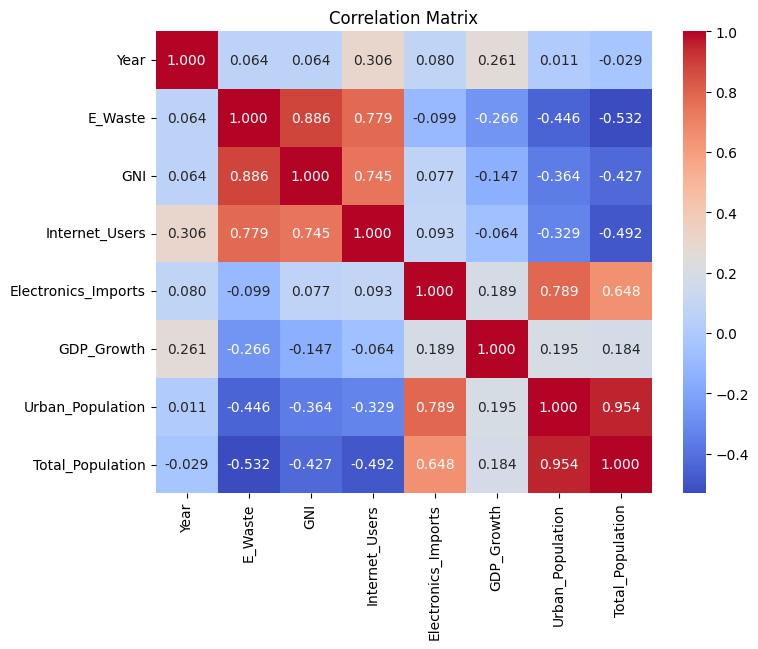

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()

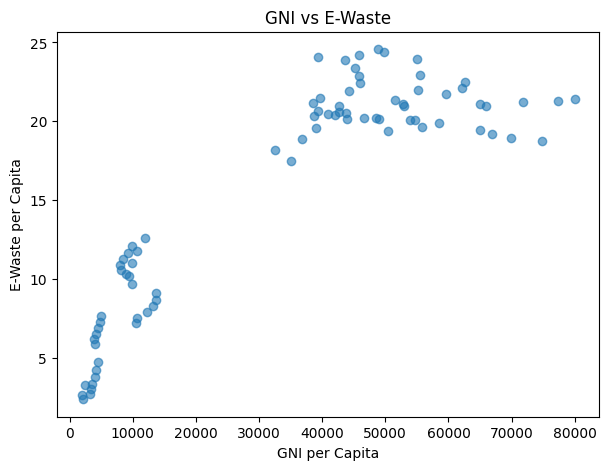

In [6]:
plt.figure(figsize=(7,5))
plt.scatter(master["GNI"], master["E_Waste"],alpha =0.6)
plt.xlabel("GNI per Capita")
plt.ylabel("E-Waste per Capita")
plt.title("GNI vs E-Waste")
plt.show()

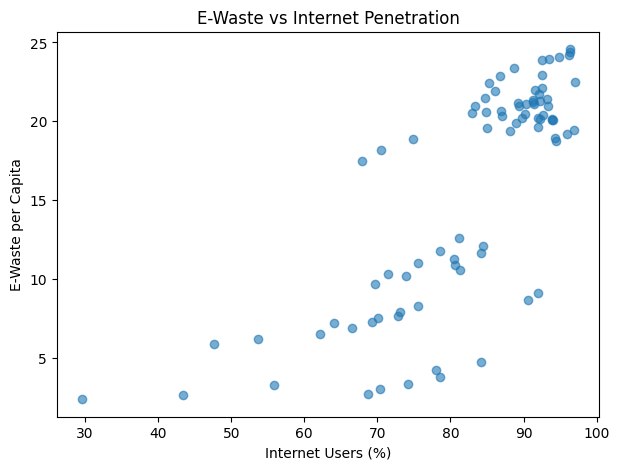

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(master["Internet_Users"], master["E_Waste"], alpha=0.6)
plt.xlabel("Internet Users (%)")
plt.ylabel("E-Waste per Capita")    
plt.title("E-Waste vs Internet Penetration")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = master[["GNI", "Internet_Users", "Electronics_Imports", "Urban_Population"]]
y = master["E_Waste"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
features = [
    "GNI",
    "Internet_Users",
    "Electronics_Imports",
    "Urban_Population"
]
x = master[features]
y = master["E_Waste"]

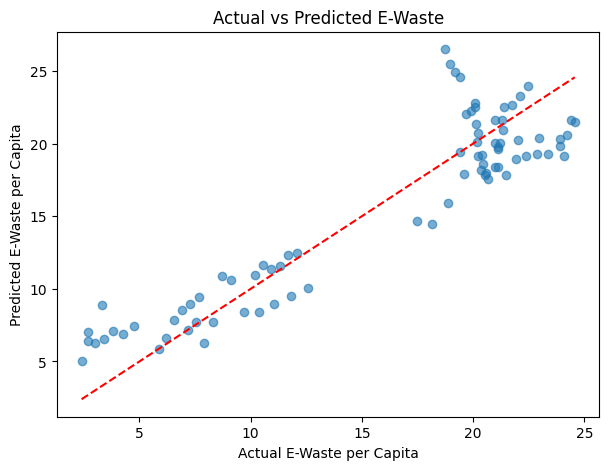

In [13]:
y_pred = model.predict(x)
plt.figure(figsize=(7,5))
plt.scatter(y,y_pred, alpha=0.6)
plt.xlabel("Actual E-Waste per Capita")
plt.ylabel("Predicted E-Waste per Capita")  
plt.title("Actual vs Predicted E-Waste")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') 
plt.show()

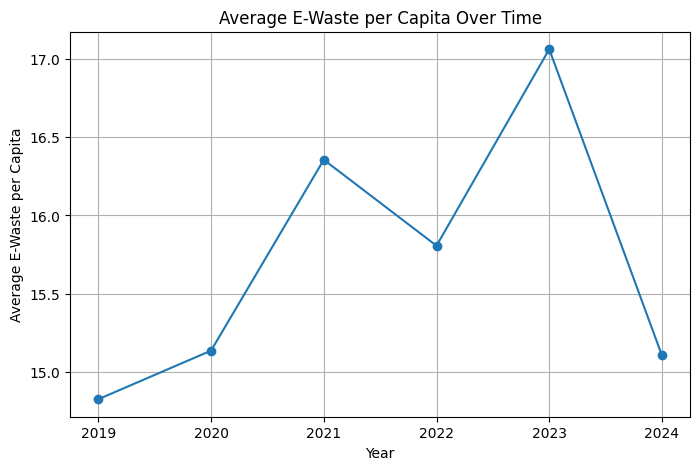

In [14]:
import matplotlib.pyplot as plt
yearly_trend = master.groupby("Year")["E_Waste"].mean().reset_index()
plt.figure(figsize=(8,5))
plt.plot(yearly_trend["Year"],yearly_trend["E_Waste"],marker="o")
plt.xlabel("Year")
plt.ylabel("Average E-Waste per Capita")
plt.title("Average E-Waste per Capita Over Time")
plt.grid(True)
plt.show()